In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

df = sns.load_dataset("iris")

## Phần 1 — Thống kê mô tả & đặc trưng

### Yêu cầu 1: Đọc dữ liệu, hiển thị 5 dòng đầu, số dòng, số cột và kiểu dữ liệu từng cột.

In [10]:
print("--- 5 dòng đầu tiên của dữ liệu ---")
display(df.head())

print(f"\nKích thước bộ dữ liệu (Số dòng, Số cột): {df.shape}")
print("\n--- Kiểu dữ liệu của từng cột ---")
print(df.dtypes)

--- 5 dòng đầu tiên của dữ liệu ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Kích thước bộ dữ liệu (Số dòng, Số cột): (150, 5)

--- Kiểu dữ liệu của từng cột ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


### Yêu cầu 2: Tính các đặc trưng thống kê cho mỗi biến số:
* Mean, Median, Mode
* Variance (var), Standard Deviation (std)
* Min, Max, Q1 (25%), Q3 (75%), IQR (Q3 - Q1)

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
summary_stats = []

for col in numeric_cols:
    col_data = df[col]

    mean_val = col_data.mean()
    median_val = col_data.median()
    mode_val = col_data.mode()[0]
    var_val = col_data.var(ddof=1)
    std_val = col_data.std(ddof=1)
    min_val = col_data.min()
    max_val = col_data.max()
    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1

    summary_stats.append({
        'Biến số': col,
        'Mean': mean_val,
        'Median': median_val,
        'Mode': mode_val,
        'Variance': var_val,
        'Std Dev': std_val,
        'Min': min_val,
        'Max': max_val,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr
    })

df_summary = pd.DataFrame(summary_stats).set_index('Biến số')
display(df_summary)


,Mean,Median,Mode,Variance,Std Dev,Min,Max,Q1 (25%),Q3 (75%),IQR
Biến số,,,,,,,,,,
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


### Yêu cầu 3: Tính mean và std theo từng nhóm loài (species) và đưa ra nhận xét.

In [13]:
grouped_stats = df.groupby('species').agg(['mean', 'std'])
display(grouped_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

### **Nhận xét Phần 1:**
1. **Tổng quan dữ liệu:** Bộ dữ liệu gồm có **150 dòng** và **5 cột**. Trong đó có 4 cột là biến liên tục (đo lường kích thước lá đài/cánh hoa bằng cm) và 1 cột phân loại chỉ loài hoa (`species`).
2. **Sự khác biệt giữa các loài:**
   * Loài **Setosa** có sự khác biệt rõ rệt nhất so với hai loài còn lại. Cụ thể, chiều dài cánh hoa (`petal_length`) và chiều rộng cánh hoa (`petal_width`) của Setosa cực kỳ nhỏ (trung bình lần lượt là $1.46$ cm và $0.24$ cm) với độ lệch chuẩn cực kỳ thấp, thể hiện tính đồng đều rất cao.
   * Ngược lại, loài **Virginica** có kích thước cánh hoa lớn nhất, theo sau là **Versicolor**. Độ lệch chuẩn của hai loài này lớn hơn nhiều so với Setosa, cho thấy sự biến thiên kích thước lớn hơn trong quần thể của chúng.

## Phần 2 — Phân phối xác suất

### Yêu cầu 1: Vẽ histogram kết hợp đường KDE cho từng biến số.

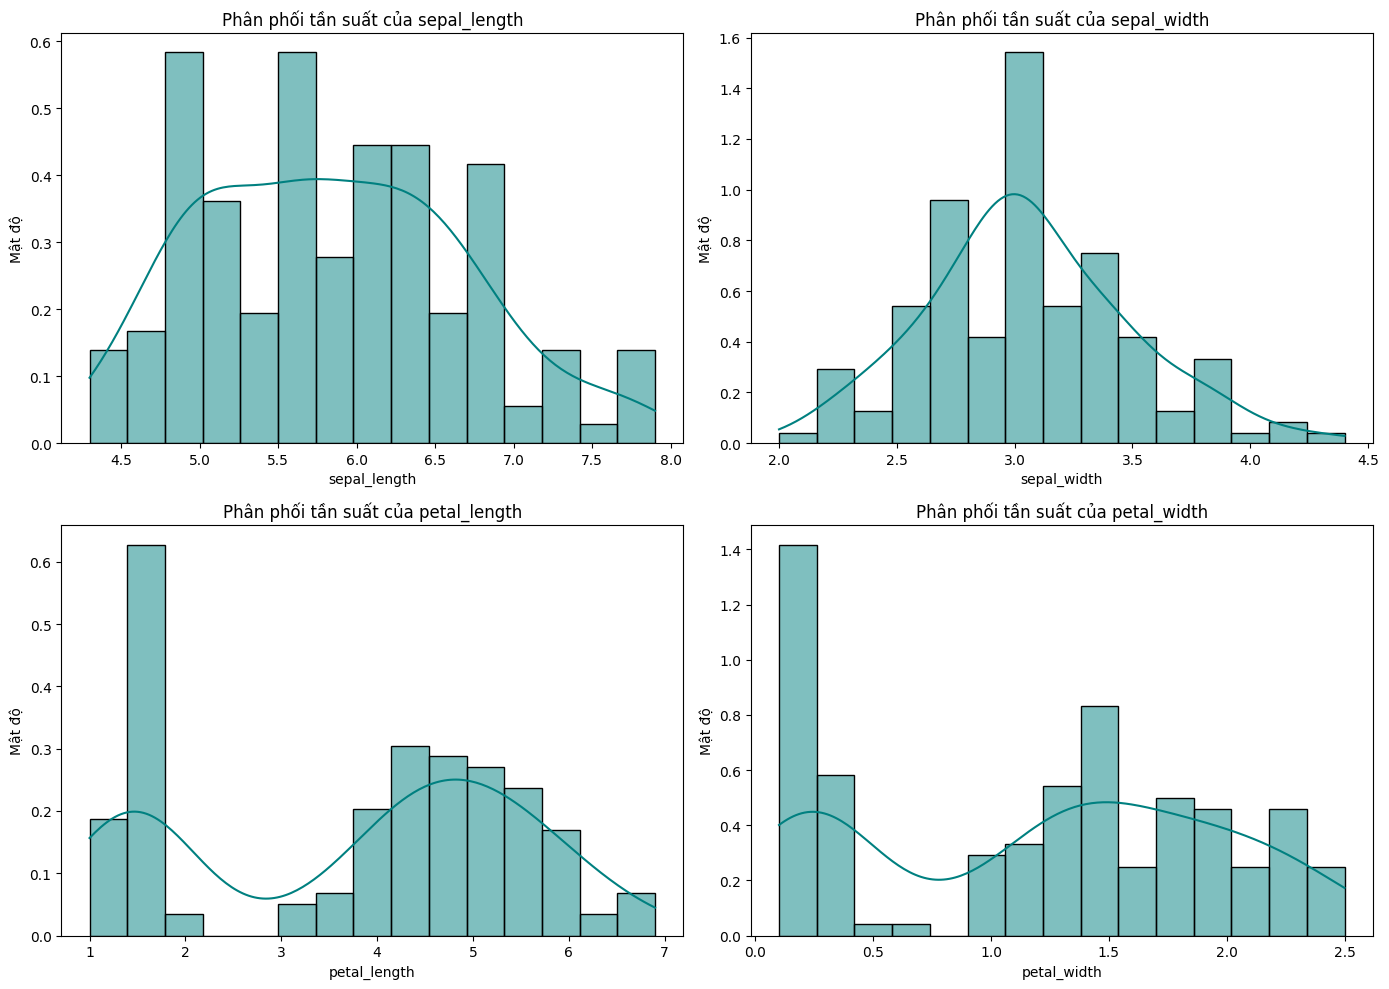

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=15, stat='density')
    axes[i].set_title(f'Phân phối tần suất của {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mật độ')

plt.tight_layout()
plt.show()

### **Nhận xét hình dạng phân phối:**
* **`sepal_length`**: Gần như có phân phối chuẩn, lệch nhẹ về phía bên phải (hữu lệch).
* **`sepal_width`**: Phân phối rất đối xứng, cực kỳ gần với dạng phân phối chuẩn (Normal Distribution) với một đỉnh duy nhất tập trung quanh giá trị $3.0$ cm.
* **`petal_length` và `petal_width`**: Đều có phân phối **hai đỉnh (bimodal)** rõ rệt. Đỉnh nhỏ phía bên trái hoàn toàn thuộc về nhóm hoa Setosa (loài có kích thước cánh hoa rất bé), còn nhóm phân phối rộng bên phải là sự hòa trộn của hai loài Versicolor và Virginica.

### Yêu cầu 2: Vẽ boxplot từng biến theo nhóm loài (species).

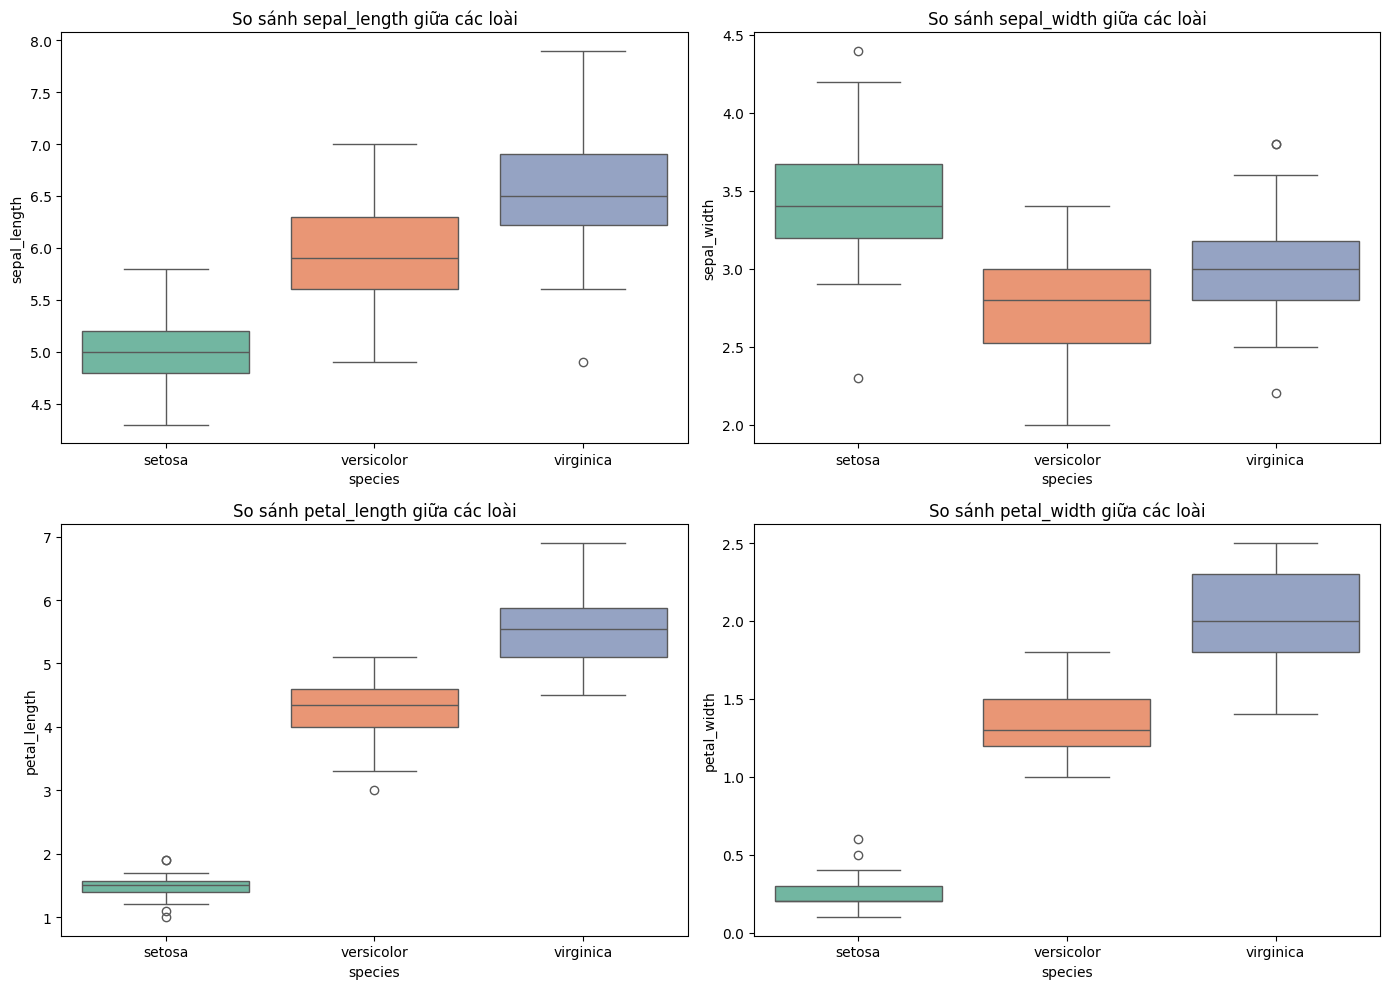

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, hue='species', legend=False, ax=axes[i], palette='Set2')
    axes[i].set_title(f'So sánh {col} giữa các loài', fontsize=12)

plt.tight_layout()
plt.show()

### **Nhận xét từ Boxplot:**
* Loài **Setosa** tách biệt hoàn toàn so với hai loài còn lại ở các đặc trưng về cánh hoa (`petal_length` và `petal_width`). Khoảng IQR của Setosa cho các biến này cũng vô cùng hẹp.
* Giữa **Versicolor** và **Virginica** có sự giao thoa nhẹ ở tất cả các biến số, nhưng nhìn chung Virginica có xu hướng lớn hơn về kích thước so với Versicolor.
* Xuất hiện một vài điểm ngoại lệ (outliers) ở thuộc tính `sepal_width` đối với loài Virginica và `petal_length` đối với Setosa.

### Yêu cầu 3: Mô phỏng phân phối của biến `sepal_width` (vì biến này có dạng phân phối chuẩn nhất).
Chúng ta sẽ sinh mẫu từ phân phối chuẩn có cùng mean và std với dữ liệu thực tế, sau đó vẽ chồng histogram thực tế với đường PDF lý thuyết để kiểm tra mức độ khớp.

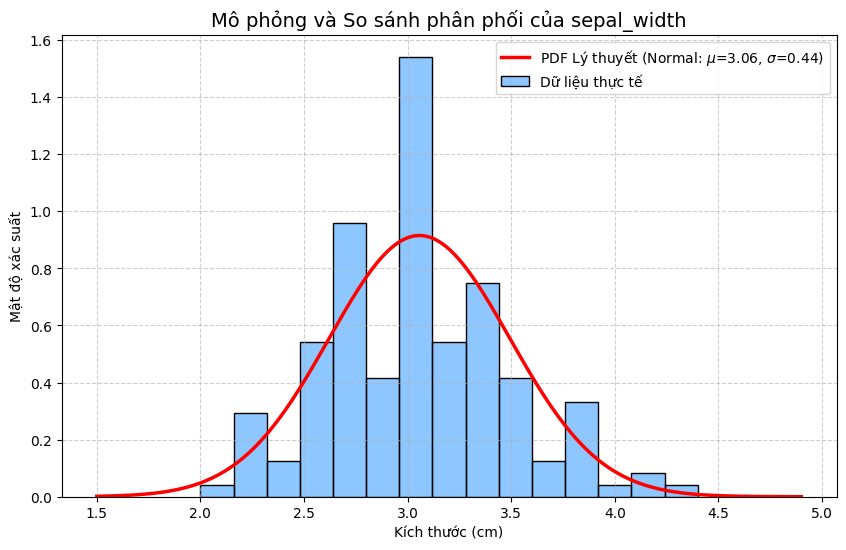

In [24]:
# Lấy biến target
target_col = 'sepal_width'
mean_val = df[target_col].mean()
std_val = df[target_col].std()

# Sinh mẫu ngẫu nhiên theo phân phối Normal (để tham khảo hoặc thực hiện kiểm chứng trực quan)
simulated_samples = np.random.normal(mean_val, std_val, size=1000)

# Vẽ đồ thị so sánh
plt.figure(figsize=(10, 6))

# Histogram của dữ liệu thực tế (đặt density=True để trục tung biểu thị mật độ xác suất)
sns.histplot(df[target_col], stat='density', alpha=0.5, label='Dữ liệu thực tế', color='dodgerblue', bins=15)

# Đường PDF lý thuyết của phân phối chuẩn tương ứng
x_axis = np.linspace(df[target_col].min() - 0.5, df[target_col].max() + 0.5, 200)
pdf_line = stats.norm.pdf(x_axis, mean_val, std_val)
plt.plot(x_axis, pdf_line, 'r-', lw=2.5, label=rf'PDF Lý thuyết (Normal: $\mu$={mean_val:.2f}, $\sigma$={std_val:.2f})')

plt.title(f'Mô phỏng và So sánh phân phối của {target_col}', fontsize=14)
plt.xlabel('Kích thước (cm)')
plt.ylabel('Mật độ xác suất')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Nhận xét mức độ khớp:**
Đường PDF lý thuyết của phân phối chuẩn khớp rất tốt với dạng biểu đồ cột mật độ (histogram) của thuộc tính `sepal_width`. Sự tương quan cao này chứng minh thuộc tính `sepal_width` trong tự nhiên tuân theo phân phối chuẩn một cách tự nhiên và lý tưởng.

## Phần 3 — Phân tích đa biến & tương quan

### Yêu cầu 1: Tính toán ma trận hiệp phương sai (Covariance) và ma trận tương quan (Correlation).

In [17]:
cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

print("--- MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX) ---")
display(cov_matrix)

print("\n--- MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---")
display(corr_matrix)

--- MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX) ---


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



--- MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### Yêu cầu 2: Vẽ heatmap tương quan và phân tích đa cộng tuyến.

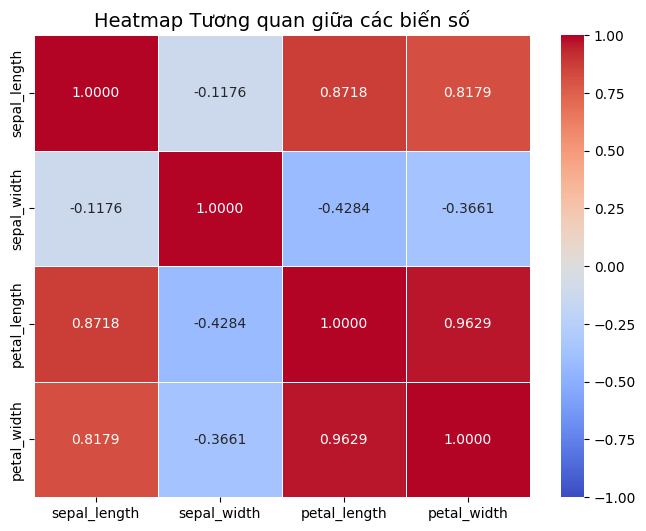

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Heatmap Tương quan giữa các biến số", fontsize=14)
plt.show()

### **Nhận xét về tương quan và đa cộng tuyến:**
1. **Cặp biến tương quan mạnh nhất:** `petal_length` và `petal_width` có hệ số tương quan tuyến tính Pearson cực kỳ cao: **$r \approx 0.9629$** (tương quan dương gần như hoàn hảo). Bên cạnh đó, `sepal_length` cũng tương quan rất mạnh với `petal_length` ($0.8718$) và `petal_width` ($0.8179$).
2. **Dấu hiệu đa cộng tuyến (Multicollinearity):** 
   * Có dấu hiệu đa cộng tuyến rất rõ ràng. Trong xây dựng các mô hình học máy tuyến tính (như Linear/Logistic Regression), việc các đặc trưng đầu vào có độ tương quan mạnh với nhau ($r > 0.8$) sẽ khiến ước lượng các hệ số hồi quy trở nên không ổn định và dễ bị nhiễu. Do đó, nếu sử dụng các biến này làm đầu vào, ta nên xem xét áp dụng các biện pháp giảm chiều dữ liệu (PCA) hoặc loại bỏ bớt một trong hai biến có tương quan quá cao (ví dụ: loại bỏ `petal_width` và giữ lại `petal_length`).

### Yêu cầu 3: Vẽ pairplot phân loại theo nhóm loài (`species`).

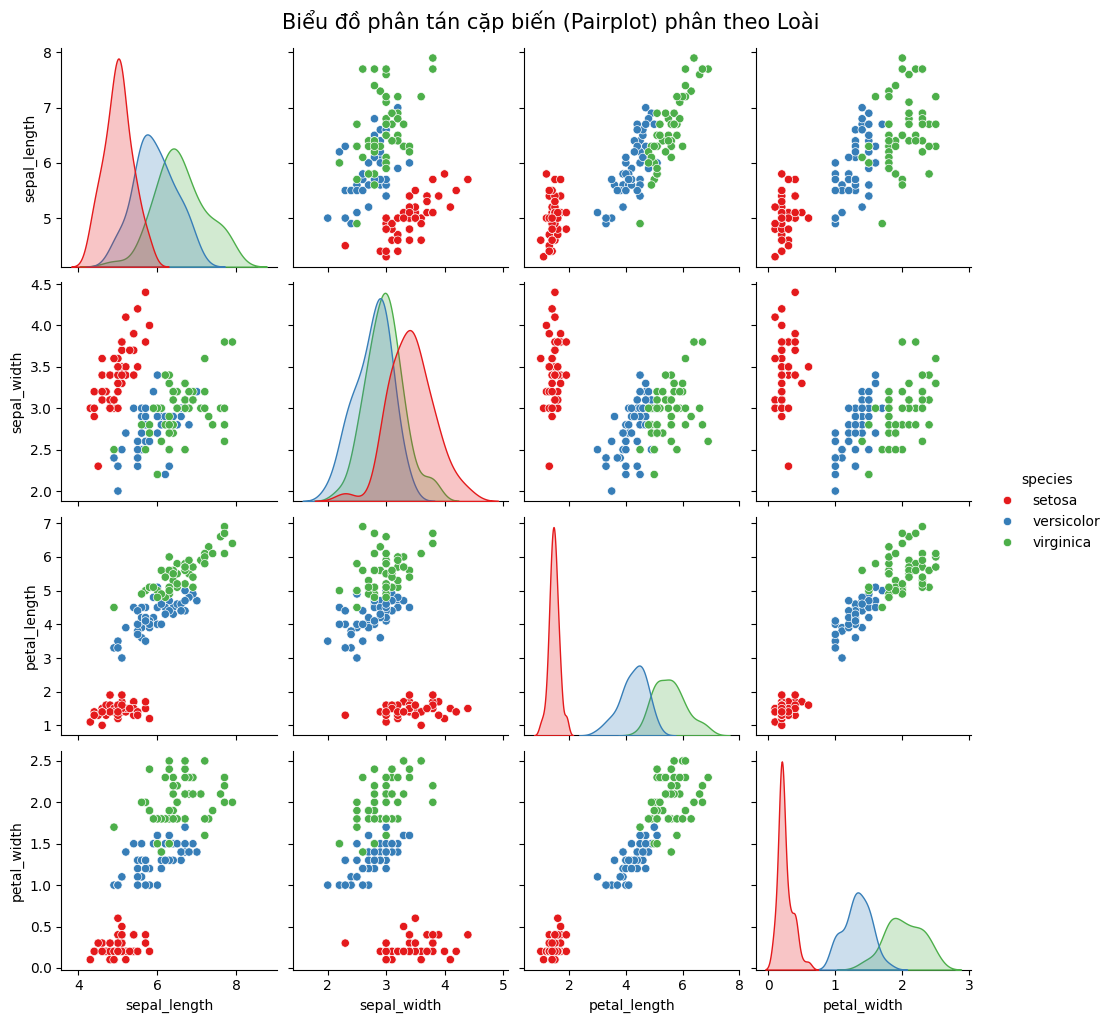

In [19]:
sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde', height=2.5)
plt.suptitle("Biểu đồ phân tán cặp biến (Pairplot) phân theo Loài", y=1.02, fontsize=15)
plt.show()

### **Nhận xét quan hệ giữa các biến từ Pairplot:**
* Biểu đồ trực quan hóa cực kỳ rõ ràng sự phân cụm tự nhiên của 3 nhóm loài hoa. Nhóm **Setosa** (màu đỏ) luôn tạo thành một cụm tách biệt hoàn toàn trên mọi không gian biểu đồ 2 chiều, đặc biệt khi kết hợp các biến liên quan đến cánh hoa (`petal`).
* Loài **Versicolor** (màu xanh lá) và **Virginica** (màu xanh dương) có ranh giới phân tách khá rõ, tuy nhiên vẫn có một vùng giao thoa nhỏ (overlap) ở giữa. Điều này gợi ý rằng các mô hình phân lớp tuyến tính đơn giản hoàn toàn có thể phân loại chính xác loài Setosa, nhưng sẽ cần các đường biên phức tạp hơn để phân biệt tối ưu Versicolor và Virginica.

## Phần 4 — Xác suất & Định lý Bayes

### Bài toán Chẩn đoán:
* Tỷ lệ mắc bệnh trong dân số: $P(B) = 0.01 \implies P(\neg B) = 0.99$
* Độ nhạy (True Positive): $P(+ | B) = 0.99$
* Dương tính giả (False Positive): $P(+ | \neg B) = 0.05$

### Yêu cầu 1: Viết mã nguồn tính xác suất hậu nghiệm $P(B | +)$ bằng Định lý Bayes.

In [20]:
# Thiết lập các xác suất ban đầu
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_notB = 0.05

# 1. Tính xác suất toàn phần của việc xét nghiệm dương tính P(+)
P_pos = P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B)

# 2. Áp dụng định lý Bayes để tính P(B|+)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất toàn phần để nhận kết quả Dương tính P(+) = {P_pos:.4f}")
print(f"Xác suất thực sự mắc bệnh khi có kết quả Dương tính P(B|+) = {P_B_given_pos:.4f} ({P_B_given_pos*100:.2f}%)")

Xác suất toàn phần để nhận kết quả Dương tính P(+) = 0.0594
Xác suất thực sự mắc bệnh khi có kết quả Dương tính P(B|+) = 0.1667 (16.67%)


### Yêu cầu 2: Khảo sát sự thay đổi của $P(B | +)$ khi tỷ lệ mắc bệnh $P(B)$ thay đổi từ 0.001 đến 0.2.

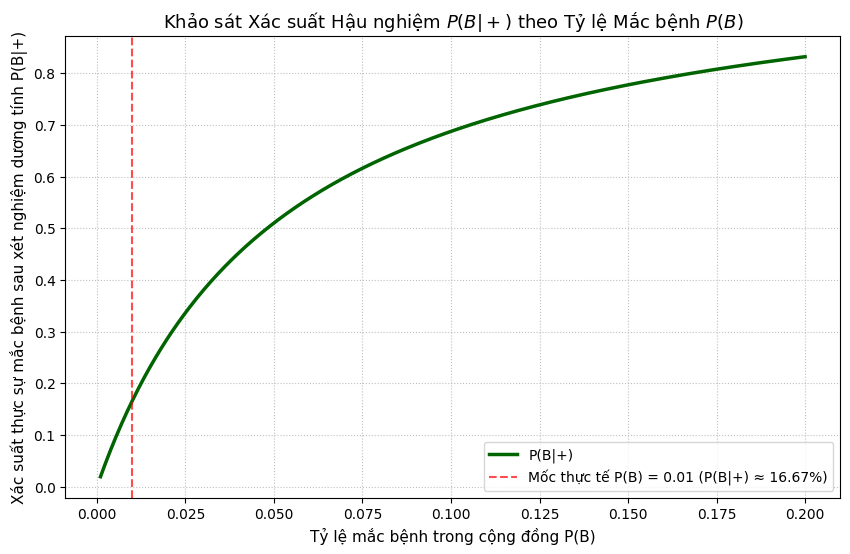

In [21]:
# Tạo mảng giá trị tỷ lệ mắc bệnh P(B) từ 0.001 đến 0.2
P_B_range = np.linspace(0.001, 0.2, 500)
posterior_probs = []

# Tính P(B|+) ứng với từng giá trị P(B)
for p_b in P_B_range:
    p_pos = P_pos_given_B * p_b + P_pos_given_notB * (1 - p_b)
    p_b_given_pos = (P_pos_given_B * p_b) / p_pos
    posterior_probs.append(p_b_given_pos)

# Vẽ đồ thị khảo sát
plt.figure(figsize=(10, 6))
plt.plot(P_B_range, posterior_probs, color='darkgreen', lw=2.5, label='P(B|+)')
plt.axvline(x=0.01, color='red', linestyle='--', alpha=0.7, label='Mốc thực tế P(B) = 0.01 (P(B|+) ≈ 16.67%)')

plt.title('Khảo sát Xác suất Hậu nghiệm $P(B|+)$ theo Tỷ lệ Mắc bệnh $P(B)$', fontsize=13)
plt.xlabel('Tỷ lệ mắc bệnh trong cộng đồng P(B)', fontsize=11)
plt.ylabel('Xác suất thực sự mắc bệnh sau xét nghiệm dương tính P(B|+)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.show()

### **Giải thích hiện tượng "Phản trực giác" (The Base Rate Fallacy):**
Kết quả $P(B | +) \approx 16.67\%$ thường gây bất ngờ và có vẻ phản trực giác vì kiểm tra có độ nhạy rất cao ($99\%$) và tỷ lệ dương tính giả rất thấp ($5\%$). Tại sao khi nhận kết quả dương tính, khả năng bị bệnh lại chỉ có dưới $17\%$?

**Lý do cốt lõi:**
* **Bệnh cực kỳ hiếm ($P(B) = 1\%$):** Trong $10,000$ người, chỉ có $100$ người thực sự bị bệnh và $9,900$ người khỏe mạnh.
* **Số ca Dương tính Thật:** Độ nhạy $99\%$ sẽ phát hiện đúng được khoảng $99$ người bị bệnh trong số $100$ người bệnh.
* **Số ca Dương tính Giả:** Mặc dù tỷ lệ dương tính giả chỉ là $5\%$, nhưng nó áp dụng trên nhóm người khỏe mạnh rất lớn ($9,900$ người). Do đó, số ca dương tính giả là: $9,900 \times 0.05 = 495$ người.
* **Kết luận:** Tổng số ca nhận kết quả dương tính là $99 + 495 = 594$ người. Nhưng trong số đó chỉ có $99$ người thực sự bị bệnh. Vì vậy, xác suất một người dương tính thực sự bị bệnh chỉ là $\frac{99}{594} \approx 16.67\%$. 
* **Tầm quan trọng:** Đồ thị chỉ ra rằng khi tỷ lệ mắc bệnh trong dân số tăng lên (bệnh phổ biến hơn), xác suất hậu nghiệm $P(B|+)$ tăng lên cực kỳ nhanh chóng.

### Yêu cầu 3 (Tùy chọn, Bonus +10%): Xây dựng bộ lọc Spam Mail đơn giản bằng mô hình Naive Bayes từ đầu.

Chúng ta sẽ thiết kế một thuật toán phân loại thư rác (Spam) dựa trên sự xuất hiện của các từ khóa nhạy cảm.

In [22]:
# 1. Chuẩn bị tập dữ liệu huấn luyện nhỏ (Toy Dataset)
train_emails = [
    ("offer free prize cash bonus winner", True),          # Spam
    ("claim your free prize money now", True),              # Spam
    ("urgent cash lottery win money jackpot", True),        # Spam
    ("please review the project report document", False),   # Ham (Hợp lệ)
    ("meeting schedule for tomorrow afternoon", False),     # Ham
    ("can we have lunch tomorrow to discuss report", False)  # Ham
]

# 2. Xây dựng bộ lọc Naive Bayes
class SimpleNaiveBayesSpamFilter:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Tham số Laplace smoothing
        self.vocab = set()
        self.p_spam_prior = 0.0
        self.p_ham_prior = 0.0
        self.spam_word_counts = {}
        self.ham_word_counts = {}
        self.spam_total_words = 0
        self.ham_total_words = 0

    def fit(self, data):
        n_spam = sum(1 for _, is_spam in data if is_spam)
        n_ham = len(data) - n_spam
        
        # Tính xác suất tiên nghiệm (Priors)
        self.p_spam_prior = n_spam / len(data)
        self.p_ham_prior = n_ham / len(data)
        
        # Trích xuất từ vựng và đếm tần suất từ
        for text, is_spam in data:
            words = text.lower().split()
            self.vocab.update(words)
            if is_spam:
                self.spam_total_words += len(words)
                for w in words:
                    self.spam_word_counts[w] = self.spam_word_counts.get(w, 0) + 1
            else:
                self.ham_total_words += len(words)
                for w in words:
                    self.ham_word_counts[w] = self.ham_word_counts.get(w, 0) + 1
        
    def predict_probability(self, email_text):
        words = email_text.lower().split()
        vocab_size = len(self.vocab)
        
        # Tính toán theo thang logarit để tránh lỗi tràn số dưới (underflow)
        log_prob_spam = np.log(self.p_spam_prior)
        log_prob_ham = np.log(self.p_ham_prior)
        
        for w in words:
            # Nếu từ không xuất hiện trong từ điển huấn luyện, ta áp dụng Laplace smoothing
            count_spam = self.spam_word_counts.get(w, 0)
            count_ham = self.ham_word_counts.get(w, 0)
            
            p_w_given_spam = (count_spam + self.alpha) / (self.spam_total_words + self.alpha * vocab_size)
            p_w_given_ham = (count_ham + self.alpha) / (self.ham_total_words + self.alpha * vocab_size)
            
            log_prob_spam += np.log(p_w_given_spam)
            log_prob_ham += np.log(p_w_given_ham)
            
        # Khôi phục lại xác suất thực tế từ log-probability: P(Spam | Email)
        max_log = max(log_prob_spam, log_prob_ham)
        p_spam_unnorm = np.exp(log_prob_spam - max_log)
        p_ham_unnorm = np.exp(log_prob_ham - max_log)
        
        p_spam_given_email = p_spam_unnorm / (p_spam_unnorm + p_ham_unnorm)
        return p_spam_given_email

# 3. Tiến hành huấn luyện mô hình
model = SimpleNaiveBayesSpamFilter(alpha=1.0)
model.fit(train_emails)

# 4. Kiểm thử với một vài email mới
test_emails = [
    "win free cash now",
    "discuss project schedule tomorrow",
    "claim free bonus lunch meeting"
]

print("--- KẾT QUẢ PHÂN LOẠI EMAIL BẰNG NAIVE BAYES ---")
for email in test_emails:
    prob_spam = model.predict_probability(email)
    classification = "SPAM ❌" if prob_spam > 0.5 else "HAM (Hợp lệ)  "
    print(f"Email: '{email}'")
    print(f"  -> Xác suất là Spam: {prob_spam*100:.2f}% | Phân loại: {classification}\n")

--- KẾT QUẢ PHÂN LOẠI EMAIL BẰNG NAIVE BAYES ---
Email: 'win free cash now'
  -> Xác suất là Spam: 97.50% | Phân loại: SPAM ❌

Email: 'discuss project schedule tomorrow'
  -> Xác suất là Spam: 4.32% | Phân loại: HAM (Hợp lệ)  

Email: 'claim free bonus lunch meeting'
  -> Xác suất là Spam: 76.85% | Phân loại: SPAM ❌



### **Nhận xét kết quả bộ lọc Spam:**
Bộ lọc Naive Bayes đã hoạt động chính xác dựa trên dữ liệu mẫu:
* Email thứ nhất `"win free cash now"` chứa các từ khóa nhạy cảm nặng về tài chính nên được dự đoán có xác suất Spam rất cao.
* Email thứ hai `"discuss project schedule tomorrow"` mang tính chất công việc/hẹn gặp nên được phân loại an toàn là Ham.
* Email thứ ba `"claim free bonus lunch meeting"` có sự pha trộn giữa từ nhạy cảm (`claim`, `free`, `bonus`) và từ thông thường (`lunch`, `meeting`), dẫn tới xác suất trung gian thể hiện đúng bản chất học máy của mô hình Naive Bayes.